In [81]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

df = pd.read_csv('data_training.csv', parse_dates=['datetime'])

train_start, train_end = '2024-01-01', '2024-03-30'
test_start, test_end = '2024-04-01', '2024-06-30'

treino = df[(df['datetime'] >= train_start) & (df['datetime'] <= train_end)]
validacao = df[(df['datetime'] >= test_start) & (df['datetime'] <= test_end)]

for df in [treino, validacao]:
    df['year'] = df['datetime'].dt.year
    df['month'] = df['datetime'].dt.month
    df['day'] = df['datetime'].dt.day    
    df['hour'] = df['datetime'].dt.hour
    df['minute'] = df['datetime'].dt.minute
    df.drop(columns=['datetime','date'], inplace=True)

X_train = treino.drop(columns=['trend'])  
y_train = treino['trend']  

X_valid = validacao.drop(columns=['trend'])  
y_valid = validacao['trend'] 

In [82]:
'''modelo = RandomForestClassifier(n_estimators=100, random_state=42)'''
modelo = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42
)

In [83]:
modelo.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=5, min_samples_split=10,
                       n_estimators=200, random_state=42)

In [84]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=9, shuffle=True, random_state=42)
cv_scores = cross_val_score(modelo, X_train, y_train, cv=cv)

print(f'Acurácia média do Cross-Validation: {np.mean(cv_scores):.4f}')

Acurácia média do Cross-Validation: 0.7434


In [85]:
y_pred = modelo.predict(X_valid)

In [86]:
acuracia = accuracy_score(y_valid, y_pred)
print(f'Acurácia nos dados de validação: {acuracia:.4f}')

Acurácia nos dados de validação: 0.5689


In [87]:
matriz_confusao = confusion_matrix(y_valid, y_pred)
print('Matriz de Confusão:')
print(matriz_confusao)

Matriz de Confusão:
[[1583 1472]
 [1213 1960]]


In [88]:
import seaborn as sns
import matplotlib.pyplot as plt

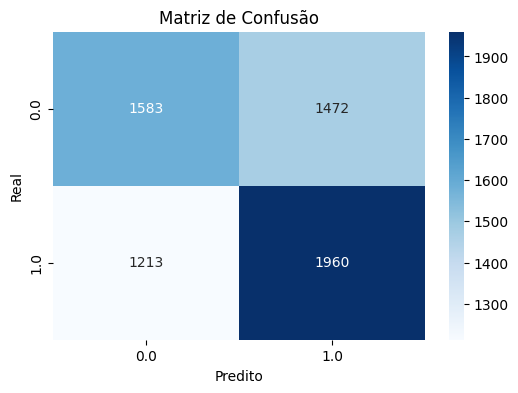

In [89]:
plt.figure(figsize=(6, 4))
sns.heatmap(matriz_confusao, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_valid), yticklabels=np.unique(y_valid))
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão')
plt.show()

In [90]:
print('Relatório de Classificação:')
print(classification_report(y_valid, y_pred))

Relatório de Classificação:
              precision    recall  f1-score   support

         0.0       0.57      0.52      0.54      3055
         1.0       0.57      0.62      0.59      3173

    accuracy                           0.57      6228
   macro avg       0.57      0.57      0.57      6228
weighted avg       0.57      0.57      0.57      6228



In [91]:
importances = modelo.feature_importances_
feature_names = X_train.columns
sorted_indices = np.argsort(importances)[::-1]

for i in sorted_indices:
    print(f"{feature_names[i]}: {importances[i]:.4f}")


day: 0.1464
hour: 0.1147
open: 0.0614
average: 0.0612
NSMA_3: 0.0611
low: 0.0589
high: 0.0586
close: 0.0580
Bands_Norm: 0.0564
volume: 0.0493
NSMA_11: 0.0432
NSMA_7: 0.0404
NSMA_5: 0.0401
NSMA_9: 0.0377
amount_stock: 0.0377
month: 0.0252
minute: 0.0210
business: 0.0173
id_ticker: 0.0115
year: 0.0000
